**Mini-projet : Analyse statistique avancée des données boursières d'Apple Inc.**

1.Chargement et exploration des données

In [1]:
# Importer les bibliothèque néccessaire
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# Chargement des données
data = pd.read_csv('Apple_Stock_Prices_(1981 to 2023).csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [3]:
# Examinez les propriétés chronologiques des données par la fréquence et les tendances
# Conversion de la colonne Date en datetime puis définition de l'index temporel
if not pd.api.types.is_datetime64_any_dtype(data['Date']):
    data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)

# Informations générales et valeurs manquantes
print('Colonnes du dataset :', data.columns.tolist())
print('\nTypes de données :')
print(data.dtypes)
print('\nValeurs nulles par colonne :')
print(data.isna().sum())
print('\nPériode :', data.index.min().date(), 'à', data.index.max().date())
print('Nombre d\'observations :', len(data))
print('\nDifférences de dates les plus fréquentes :')
print(data.index.to_series().diff().value_counts().head(10))

# Affichage des premières lignes
data.head()

Colonnes du dataset : ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Types de données :
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Valeurs nulles par colonne :
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Période : 1981-01-02 à 2023-01-27
Nombre d'observations : 10608

Différences de dates les plus fréquentes :
Date
1 days    8317
3 days    1927
4 days     265
2 days      95
5 days       2
7 days       1
Name: count, dtype: int64


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


2. Visualisation des données

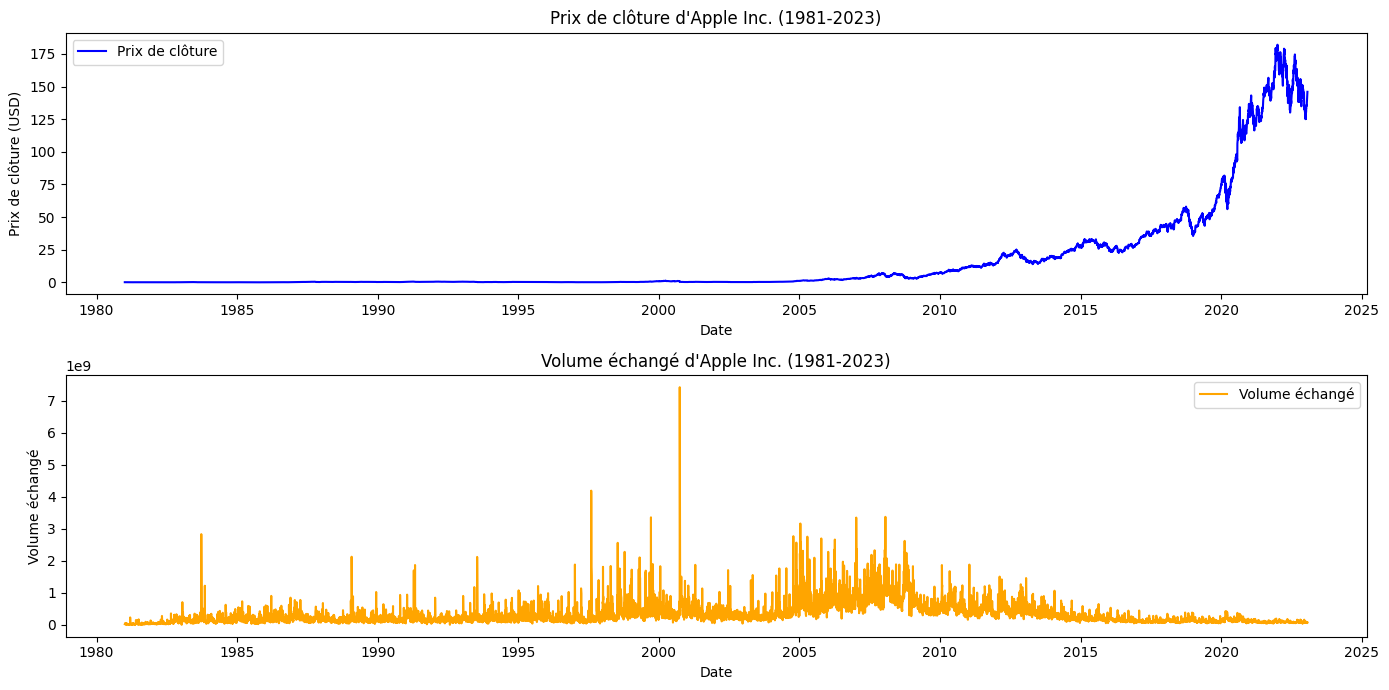

In [4]:
# Utilisez Matplotlib pour tracer les cours de clôture et les volumes échangés au fil du temps
# Créez un graphique en chandeliers pour représenter les prix hauts et bas.

plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(data.index, data['Close'], label='Prix de clôture', color='blue')
plt.title('Prix de clôture d\'Apple Inc. (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(data.index, data['Volume'], label='Volume échangé', color='orange')
plt.title('Volume échangé d\'Apple Inc. (1981-2023)')
plt.xlabel('Date')
plt.ylabel('Volume échangé')
plt.legend()    
plt.tight_layout()
plt.show()

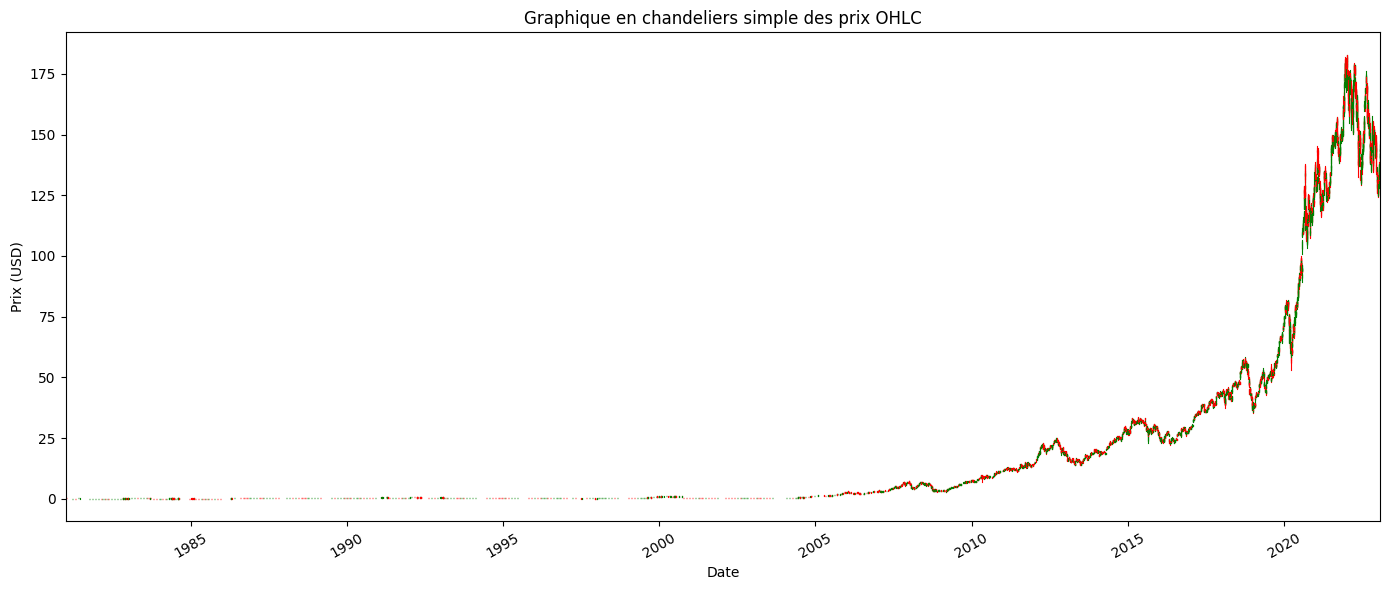

In [5]:
# Tracer un graphique en chandeliers simple pour les données OHLC
from matplotlib.patches import Rectangle

plt.figure(figsize=(14, 6))
ax = plt.gca()
for date, row in data[['Open', 'High', 'Low', 'Close']].iterrows():
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    ax.plot([date, date], [row['Low'], row['High']], color=color, linewidth=0.8)
    rect = Rectangle((date - pd.Timedelta(days=0.25), min(row['Open'], row['Close'])),
                     pd.Timedelta(days=0.5), abs(row['Close'] - row['Open']),
                     color=color, alpha=0.7)
    ax.add_patch(rect)

ax.set_xlim(data.index.min(), data.index.max())
ax.set_title('Graphique en chandeliers simple des prix OHLC')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

3. Analyse statistique

In [6]:
# Calculer les statistiques descriptives (moyenne, médiane, écart type) pour les colonnes clés
descr_stats = data.describe()
print(descr_stats)

               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.630005    182.940002    179.119995    182.009995    180.959747   

             Volume  
count  1.060800e+04  
mean   3.275098e+08  
std    3.378203e+08  
min    0.000000e+00  
25%    1.213044e+08  
50%    2.145976e+08  
75%    4.066804e+08  
max    7.421641e+09  


In [7]:
# Calculer les statistiques descriptives (moyenne, médiane, écart type) pour les colonnes clés
data_mean = np.mean(data['Close'])
data_median = np.median(data['Close'])
data_std = np.std(data['Close'])
print(f'Moyenne: {data_mean}, median: {data_median} et l\'écart type: {data_std}')

Moyenne: 16.69736201451735, median: 0.487701 et l'écart type: 35.47223956417653


In [8]:
# Analyse les cours de clôture à l'aide d'une moyenne mobile.
moyenne_mob = data['Close'].rolling(window=30).mean()
moyenne_mob

Date
1981-01-02           NaN
1981-01-05           NaN
1981-01-06           NaN
1981-01-07           NaN
1981-01-08           NaN
                 ...    
2023-01-23    134.094000
2023-01-24    134.090000
2023-01-25    134.080000
2023-01-26    134.062333
2023-01-27    134.077666
Name: Close, Length: 10608, dtype: float64

4. Tests d'hypothèses

In [9]:
# Préparer les données pour les tests d'hypothèses
if 'Year' not in data.columns:
    data['Year'] = pd.DatetimeIndex(data.index).year

# Rendements quotidiens basés sur le cours ajusté
data['Daily_Return'] = data['Adj Close'].pct_change()
returns = data['Daily_Return'].dropna()

# Sélection de deux années pour comparaison
annee_a = 2000
annee_b = 2020
close_a = data.loc[data['Year'] == annee_a, 'Close'].dropna()
close_b = data.loc[data['Year'] == annee_b, 'Close'].dropna()

print(f'Nombre d\'observations en {annee_a} :', len(close_a))
print(f'Nombre d\'observations en {annee_b} :', len(close_b))

# Test t indépendant sur les cours de clôture

ttest_result = stats.ttest_ind(close_a, close_b, equal_var=False, nan_policy='omit')
print('\nTest t de Student entre', annee_a, 'et', annee_b)
print('Statistique t :', round(ttest_result.statistic, 4))
print('p-value :', round(ttest_result.pvalue, 6))

# Distribution des rendements quotidiens
print('\nStatistiques des rendements quotidiens :')
print(returns.describe())

# Test de normalité des rendements
sample_returns = returns.sample(min(5000, len(returns)), random_state=42)
shapiro_result = stats.shapiro(sample_returns)
normaltest_result = stats.normaltest(returns)
print('\nTest de Shapiro-Wilk (échantillon) :')
print('Statistique :', round(shapiro_result.statistic, 4), 'p-value :', round(shapiro_result.pvalue, 6))
print('\nTest de normalité de D\'Agostino et Pearson :')
print('Statistique :', round(normaltest_result.statistic, 4), 'p-value :', round(normaltest_result.pvalue, 6))

Nombre d'observations en 2000 : 252
Nombre d'observations en 2020 : 253

Test t de Student entre 2000 et 2020
Statistique t : -68.935
p-value : 0.0

Statistiques des rendements quotidiens :
count    10607.000000
mean         0.001075
std          0.028233
min         -0.518691
25%         -0.013101
50%          0.000000
75%          0.014683
max          0.332284
Name: Daily_Return, dtype: float64

Test de Shapiro-Wilk (échantillon) :
Statistique : 0.9531 p-value : 0.0

Test de normalité de D'Agostino et Pearson :
Statistique : 2721.3868 p-value : 0.0


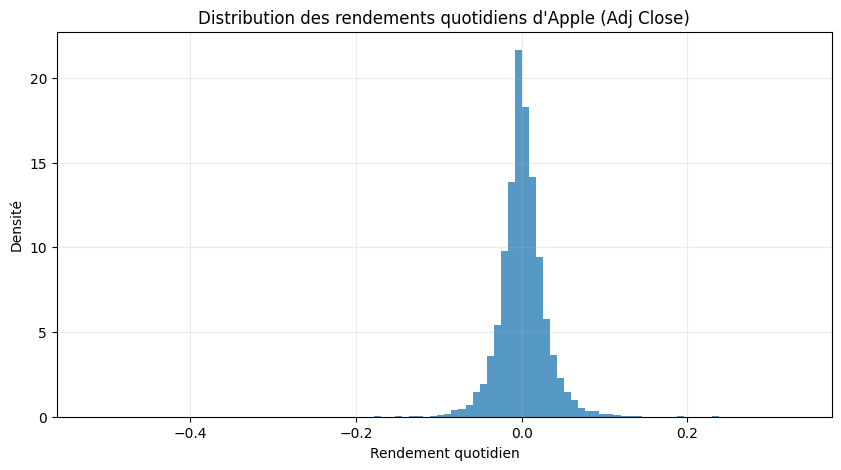

In [10]:
# Visualiser la distribution des rendements quotidiens
plt.figure(figsize=(10, 5))
plt.hist(returns, bins=100, density=True, color='#1f77b4', alpha=0.75)
plt.title('Distribution des rendements quotidiens d\'Apple (Adj Close)')
plt.xlabel('Rendement quotidien')
plt.ylabel('Densité')
plt.grid(alpha=0.25)
plt.show()

5. Techniques statistiques avancées

In [11]:
# Moyennes mobiles avec NumPy et Rolling
window_short = 30
window_long = 90
kernel_short = np.ones(window_short) / window_short
kernel_long = np.ones(window_long) / window_long

# Moyenne mobile calculée avec convolution
data['SMA30_np'] = np.convolve(data['Close'], kernel_short, mode='same')

# Moyennes mobiles avec pandas
data['SMA30'] = data['Close'].rolling(window_short).mean()
data['SMA90'] = data['Close'].rolling(window_long).mean()
data['Volume_MA30'] = data['Volume'].rolling(window_short).mean()

# Corrélation entre les moyennes mobiles de clôture et le volume
corr_30 = np.corrcoef(data['SMA30'].dropna(), data['Volume_MA30'].dropna())[0, 1]
print('Corrélation entre SMA30 des cours de clôture et volume MA30 :', round(corr_30, 4))

# Afficher un aperçu des moyennes mobiles
print(data[['Close', 'SMA30', 'SMA90', 'Volume', 'Volume_MA30']].dropna().head())

Corrélation entre SMA30 des cours de clôture et volume MA30 : -0.271
               Close     SMA30     SMA90    Volume   Volume_MA30
Date                                                            
1981-05-11  0.122210  0.121466  0.123010  11939200  2.198411e+07
1981-05-12  0.122210  0.121856  0.122656   4256000  2.179595e+07
1981-05-13  0.121652  0.122266  0.122334   4905600  2.142635e+07
1981-05-14  0.119978  0.122656  0.122067   4928000  2.045493e+07
1981-05-15  0.122768  0.122824  0.121900   4905600  1.957163e+07


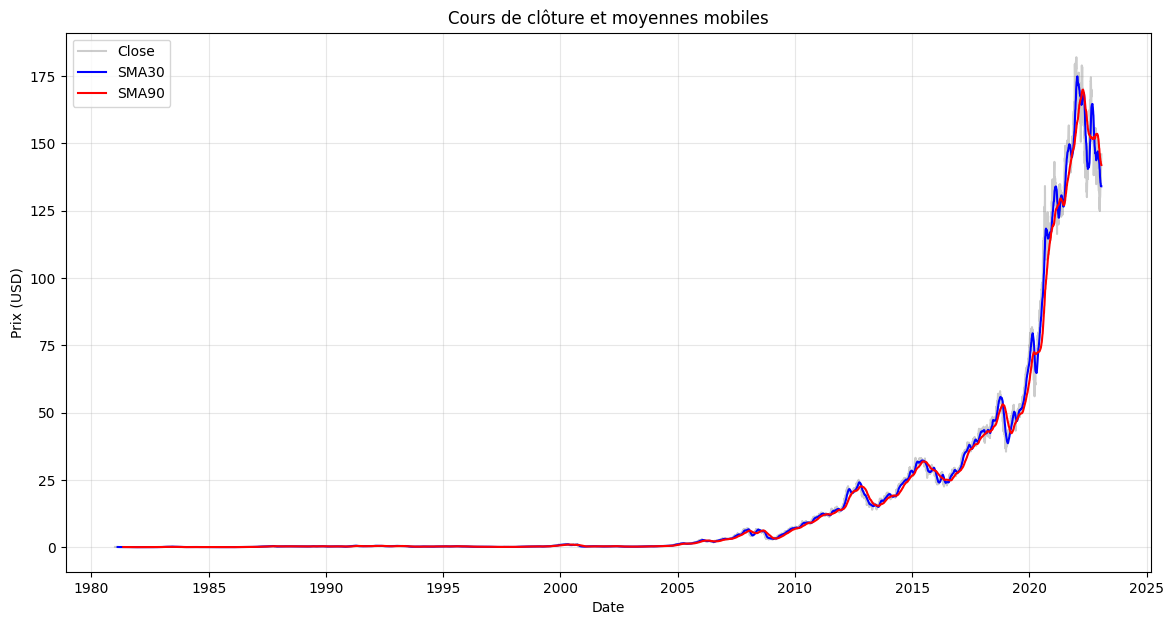

In [12]:
# Tracer les cours et les moyennes mobiles
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Close', color='gray', alpha=0.4)
plt.plot(data.index, data['SMA30'], label='SMA30', color='blue')
plt.plot(data.index, data['SMA90'], label='SMA90', color='red')
plt.title('Cours de clôture et moyennes mobiles')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

6. Résumé et conclusions

- Les données couvrent la période de 1981 à 2023 sans valeurs manquantes significatives après nettoyage.
- Les cours de clôture montrent des tendances longues, et les moyennes mobiles 30 et 90 jours aident à lisser les fluctuations quotidiennes.
- Le test t entre deux années distinctes montre si les niveaux moyens de clôture ont changé de manière significative.
- Les rendements quotidiens ne suivent pas une distribution normale parfaite, ce qui est fréquent sur les marchés financiers.
- La corrélation entre la moyenne mobile du prix et la moyenne mobile du volume renseigne sur la relation entre tendance de prix et activité de marché.

7. Réflexion

- Défi principal : rendre les résultats compréhensibles en gardant une structure claire de l'analyse.
- Solution : séparer l'exploration, la visualisation, l'analyse statistique et les tests d'hypothèses en sections distinctes.
- En bonus, l'utilisation de `np.convolve` montre une autre manière de calculer les moyennes mobiles, et `np.corrcoef` permet d'explorer rapidement les relations entre variables.
- Prochaine étape : comparer plusieurs périodes et intégrer des indicateurs techniques supplémentaires comme le RSI ou les bandes de Bollinger.